# Simulation Methodology

---Patient Modeling Workspace---

1. Contour Cell Layer (at the bottom of the cell flask).
2. Set an External ROI that extends from above the top of the medium to 8.06 cm below the isocentre (=snout position)
3. Contour an ROI 'Modulator' extending 6 mm upwards from the bottom of the external ROI. This is to model the 6 mm solid water in the high LET setup. 
4. Contour an ROI 'AirGap' between the 'Modulator' and the bottom of the solid water plate.

![alt text](<../LET calculation in setup from RS sim/Final RS sims/Low LET/Patient Modelling.png>)

---Plan Design Workspace---

5. Set gantry angle to 180 degrees.
6. Set snout position to 8.25 cm (closest we can get to 8.06 due to safety margin, I've established in the calculation 'Does 0.13 cm snout position matter' that this matters little).
7. Copy the MUs from the treatment plan and enter for the beam. Ensure that the MU/spot is the same as in the treatment plan (this is more important than the total MU)

![alt text](<../LET calculation in setup from RS sim/Final RS sims/Low LET/Plan Design.png>)

---Plan Optimisation Workspace---

8. Set up the spots (16.8x16.8 field with 0.8 spacing, yields 22x22 spots, energy 69 MeV) using the treatment plan parameters.
9. Run dose calculation including 'Calculate LET'

![alt text](<../LET calculation in setup from RS sim/Final RS sims/Low LET/Plan Optimisation.png>)


---Plan Evaluation Workspace---

10. Used the LET export script to export the dose and LET data that I'm analysing here.

***For low LET***
The 'Solid Water Modulator' ROI gets a material override to 'Air'. (Step 4)
The beam gets no range shifter. (Step 6)

***For high LET***
The 'Solid Water Modulator' ROI gets a material override to 'Water'. (Step 4)
Add RS2 as range shifter to the beam. (Step 6)

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

In [4]:
def Calculate_BP_Positions(path_pos1, path_pos2, nominal_dose):
    #Calculate the dose and LET in different Bragg Peak Positions from the csv data that results from the LET export script in RayStation

    #Inputs
    #path_pos1 = path to the file for the low LET position
    #path_pos2 = path to the file for the high LET position
    #nominal_dose = int specifying the dose in the plan

    #Outputs
    #LET and dose map in the cell layer, for both positions
    #LET and dose difference maps between the two positions
    #Printed statistics


    ### PRE-PROCESSING ###############################################################################################
    data_pos1 = pd.read_csv(path_pos1)
    data_pos2 = pd.read_csv(path_pos2)


    ### PRINTING STATISTICS #########################################################################################
    print("----Proximal BP position data----")
    print("Mean dose: " + str(round(np.mean(data_pos1['Physical_dose']),2)) + " Gy")
    print("Max dose: " + str(round(np.max(data_pos1['Physical_dose']),2)) + " Gy")
    print("Min dose: " + str(round(np.min(data_pos1['Physical_dose']),2)) + " Gy")
    print("Mean LET: " + str(round(np.mean(data_pos1['LET_keV_per_um']),1)) + " keV/um")
    print("Max LET: " + str(round(np.max(data_pos1['LET_keV_per_um']),2)) + " keV/um")
    print("Min LET: " + str(round(np.min(data_pos1['LET_keV_per_um']),2)) + " keV/um")

    print("----Distal BP position data----")
    print("Mean dose: " + str(round(np.mean(data_pos2['Physical_dose']),2)) + " Gy")
    print("Max dose: " + str(round(np.max(data_pos2['Physical_dose']),2)) + " Gy")
    print("Min dose: " + str(round(np.min(data_pos2['Physical_dose']),2)) + " Gy")
    print("Mean LET: " + str(round(np.mean(data_pos2['LET_keV_per_um']),1)) + " keV/um")
    print("Max LET: " + str(round(np.max(data_pos2['LET_keV_per_um']),2)) + " keV/um")
    print("Min LET: " + str(round(np.min(data_pos2['LET_keV_per_um']),2)) + " keV/um")



    ### WRITE IMAGE ARRAY OF LET AND DOSE ############################################################################
    #Due to the fineness of the dose grid the cell layer also has multiple depth values, I'll map the middle one
    half = int(len(data_pos1['y_mm'].unique())/2)
    print(len(data_pos1['y_mm'].unique()))
    slice_pos1 = data_pos1[data_pos1['y_mm']==data_pos1['y_mm'].unique()[half]]
    slice_pos2 = data_pos2[data_pos2['y_mm']==data_pos2['y_mm'].unique()[half]]
    
    #Set up image array
    x_vals = slice_pos1['x_mm'].unique()
    z_vals = slice_pos1['z_mm'].unique()
    let_pos1 = np.zeros([int(len(z_vals)), int(len(x_vals))])
    let_pos2 = np.zeros([int(len(z_vals)), int(len(x_vals))])
    dose_pos1 = np.zeros([int(len(z_vals)), int(len(x_vals))])
    dose_pos2 = np.zeros([int(len(z_vals)), int(len(x_vals))])

    #Populate image array 1 with LET and dose values
    for i in slice_pos1.index.tolist():
        datapoint = slice_pos1.loc[i]
        x = datapoint.x_mm
        z = datapoint.z_mm
        let = datapoint.LET_keV_per_um
        dose = datapoint.Physical_dose

        x_index = np.where(x_vals == x)
        z_index = np.where(z_vals == z)

        let_pos1[z_index, x_index] = let
        dose_pos1[z_index, x_index] = dose

    #Populate image array 2 with let and dose values
    for i in slice_pos2.index.tolist():
        datapoint = slice_pos2.loc[i]
        x = datapoint.x_mm
        z = datapoint.z_mm
        let = datapoint.LET_keV_per_um
        dose = datapoint.Physical_dose

        x_index = np.where(x_vals == x)
        z_index = np.where(z_vals == z)

        let_pos2[z_index, x_index] = let
        dose_pos2[z_index, x_index] = dose

    ### PLOTTING LET AND DOSE MAP ################################################################################
    fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

    plt.suptitle('LET maps for both BP positions, ' + str(nominal_dose) + ' Gy')
    data = ((let_pos1, let_pos2))
    titles = (('LET map proximal', 'LET map distal'))
 
    for col in range(2):
        ax = axes[col]
        ax.set_title(titles[col])
        pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=18)
    fig.colorbar(pcm, ax=axes, shrink=0.6)


    ### PLOTTING THE DIFFERENCE MAP ##############################################################################
    fig = plt.figure()
    plt.suptitle('LET difference map, ' + str(nominal_dose) + ' Gy')
    plt.pcolormesh(let_pos2 - let_pos1, cmap='bwr', vmin=0, vmax=18)
    plt.colorbar()

# Results 2 Gy

----Proximal BP position data----
Mean dose: 1.94 Gy
Max dose: 4.91 Gy
Min dose: 0.26 Gy
Mean LET: 16.2 keV/um
Max LET: 18.77 keV/um
Min LET: 12.0 keV/um
----Distal BP position data----
Mean dose: 1.94 Gy
Max dose: 4.91 Gy
Min dose: 0.26 Gy
Mean LET: 16.2 keV/um
Max LET: 18.77 keV/um
Min LET: 12.0 keV/um
2


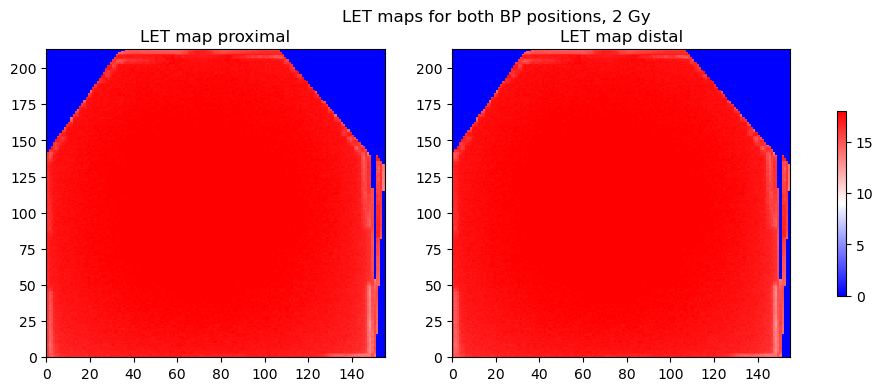

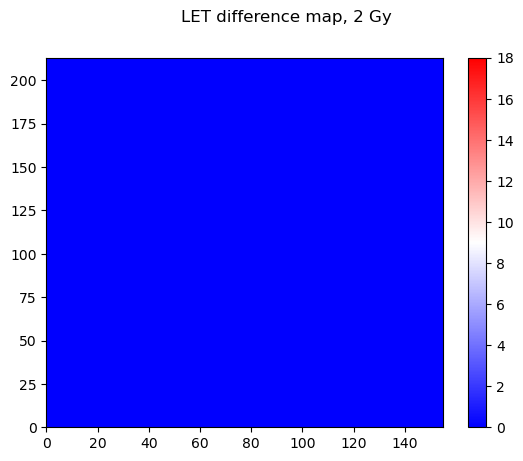

In [ ]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims\Low LET\Final RS sim low LET 2 Gy.csv"
path_highLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims\High LET\Final RS high LET 2 Gy.csv"

Calculate_BP_Positions(path_lowLET, path_highLET, 2)